In [5]:
#------------------------------------------------------------------------------
#Here's the validation block on its own. It includes everything necessary from main the script up through the min_modulus definition (it needs chi_poly, required_prec, min_modulus, and the exact-data block that builds deformed_h_list):

#------------------------------------------------------------------------------------------------------
# ===== Min-moduli precision validation (c = 1), standalone =====
from sage.all import (QQ, polygen, ComplexField, delta_qexp,
                      nth_prime, binomial, factorial)
import pickle
import ast

x    = polygen(QQ)
NMAX = 500          # must cover the largest n in `sample` below
c    = 1 #<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
ACCURACY_BITS = 60
GUARD_BITS    = 32

def h_sequence_from_j(j_list):
    L = len(j_list); h = [QQ(1)]
    for n in range(1, L + 1):
        s = sum(j_list[r-1]*h[n-r] for r in range(1, n))
        h.append((j_list[n-1] + s)/n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("need h_0 = 1")
    L = len(h_list) - 1; j = []
    for n in range(1, L + 1):
        s = sum(j[r-1]*h_list[n-r] for r in range(1, n))
        j.append(n*h_list[n] - s)
    return j

# ---- exact data (no precision loss here) ----
D = delta_qexp(nth_prime(NMAX) + 2)
def elliptic_fourier_expansions(level, num_terms):
    db = CremonaDatabase()
    expansions = []

    for curve_label in db.curves(level):
        if curve_label.endswith('1'):
            full_label = str(level) + curve_label
            E = EllipticCurve(full_label)
            coeffs = [(n, E.an(n)) for n in range(1, num_terms + 1)]
            expansions.append((full_label, coeffs))

    return expansions


level = 11
# near the top, define the sample once so bound can track it
sample = (150, 300, 500)
bound  = nth_prime(max(sample) + 2)   # = 3583 -> 502 prime coeffs, indices 0..503
output = elliptic_fourier_expansions(level, bound)
data=output[0]
label = data[0]
expansion=data[1]
print("label:", label)
prime_list_no_offset=[pair for pair in expansion if is_prime(pair[0])]
coeffs_list=[pair[1] for pair in prime_list_no_offset]

h_list=[1]+coeffs_list # h_0 = 1 required by the lemmas
j_list = j_sequence_from_h(h_list)
deformed_h_list = h_sequence_from_j([QQ(c)] + j_list)
# right after: deformed_h_list = h_sequence_from_j([QQ(c)] + j_list)
assert len(deformed_h_list) > max(sample), (
    f"deformed_h_list too short: len={len(deformed_h_list)}, "
    f"need > {max(sample)} (bound={bound}, prime coeffs={len(coeffs_list)})"
)
def deformed_h(n): return deformed_h_list[n]

def chi_poly(n):
    return sum(binomial(n, r)*factorial(r)*deformed_h(r)*(-1)**r * x**(n - r)
               for r in range(n + 1))

def required_prec(chi):
    span = max(cf.numerator().abs().nbits() - cf.denominator().nbits()
               for cf in chi.coefficients())
    return int(span) + ACCURACY_BITS + GUARD_BITS

def min_modulus(chi, prec):
    CC = ComplexField(prec)
    return min(r.abs() for r in chi.roots(ring=CC, multiplicities=False))

# ---- the validation ----
def validate(sample=(150, 300, 500), extra=256):
    print("  n    prec    min modulus            rel. drift   verdict")
    for n in sample:
        chi  = chi_poly(n)
        prec = required_prec(chi)
        mu   = min_modulus(chi, prec)
        mu2  = min_modulus(chi, prec + extra)
        rel  = abs(mu - mu2)/mu2 if mu2 != 0 else abs(mu - mu2)
        verdict = "OK" if rel < 1e-12 else "RAISE ACCURACY_BITS"
        print("%3d  %6d  %-22.14f  %.2e   %s"
              % (n, prec, float(mu), float(rel), verdict))

validate()

label: 11a1
  n    prec    min modulus            rel. drift   verdict
150    1136  76.08020778709924       0.00e+00   OK
300    2485  154.50644533299635      0.00e+00   OK
500    4454  259.49504111684587      0.00e+00   OK


n= 10 prec=  139 mu=20.233137 elapsed=0.0min
n= 20 prec=  209 mu=44.946809 elapsed=0.0min
n= 30 prec=  287 mu=70.155044 elapsed=0.0min
n= 40 prec=  370 mu=95.497204 elapsed=0.0min
n= 50 prec=  457 mu=120.907511 elapsed=0.0min
n= 60 prec=  547 mu=146.359196 elapsed=0.0min
n= 70 prec=  639 mu=171.838593 elapsed=0.1min
n= 80 prec=  733 mu=197.337814 elapsed=0.1min
n= 90 prec=  829 mu=222.851905 elapsed=0.2min
n=100 prec=  927 mu=248.377554 elapsed=0.2min
n=110 prec= 1026 mu=273.912438 elapsed=0.3min
n=120 prec= 1126 mu=299.454869 elapsed=0.4min
n=130 prec= 1228 mu=325.003581 elapsed=0.6min
n=140 prec= 1331 mu=350.557599 elapsed=0.8min
n=150 prec= 1435 mu=376.116159 elapsed=1.0min
n=160 prec= 1539 mu=401.678650 elapsed=1.3min
n=170 prec= 1645 mu=427.244577 elapsed=1.6min
n=180 prec= 1751 mu=452.813530 elapsed=2.0min
n=190 prec= 1859 mu=478.385172 elapsed=2.4min
n=200 prec= 1967 mu=503.959215 elapsed=3.0min
n=210 prec= 2076 mu=529.535418 elapsed=3.6min
n=220 prec= 2185 mu=555.113572 elapsed

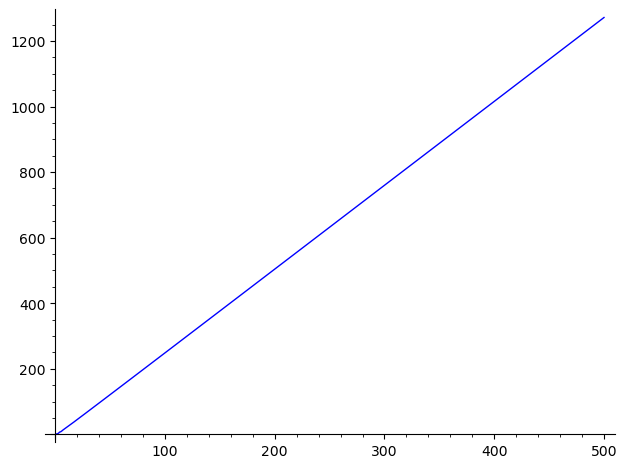

In [1]:
# ===== Oscillating spectra: min-moduli with adaptive precision =====
import time
from sage.all import (QQ, polygen, ComplexField, delta_qexp,
                      binomial, factorial, list_plot)   # nth_prime no longer needed
x    = polygen(QQ)
NMAX = 500
c    = 1   # header said c=1; set to whatever you actually mean
ACCURACY_BITS = 60
GUARD_BITS    = 32
PRINT_EVERY   = 10          # was `n % 1` (every step); set to 1 to restore that

def h_sequence_from_j(j_list):
    L = len(j_list); h = [QQ(1)]
    for n in range(1, L + 1):
        s = sum(j_list[r-1]*h[n-r] for r in range(1, n))
        h.append((j_list[n-1] + s)/n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1: raise ValueError("need h_0 = 1")
    L = len(h_list) - 1; j = []
    for n in range(1, L + 1):
        s = sum(j[r-1]*h_list[n-r] for r in range(1, n))
        j.append(n*h_list[n] - s)
    return j

# ---- exact data: contiguous coefficients a_1..a_NMAX of Delta (no precision loss) ----
D = delta_qexp(NMAX + 2)        # was nth_prime(NMAX)+2 (=3573) — a relic of the
                                # prime-indexed version; here you only need NMAX terms
h_list = [QQ(1)] + [QQ(D[k]) for k in range(1, NMAX + 1)]
j_list = j_sequence_from_h(h_list)
deformed_h_list = h_sequence_from_j([QQ(c)] + j_list)

# fail loudly with context instead of an IndexError if lengths ever drift
assert len(deformed_h_list) > NMAX, (
    f"deformed_h_list too short: len={len(deformed_h_list)}, need > {NMAX} "
    f"(D terms={NMAX}, c={c})"
)

def deformed_h(n): return deformed_h_list[n]

def chi_poly(n):
    return sum(binomial(n, r)*factorial(r)*deformed_h(r)*(-1)**r * x**(n - r)
               for r in range(n + 1))

def required_prec(chi):
    span = max(cf.numerator().abs().nbits() - cf.denominator().nbits()
               for cf in chi.coefficients())
    return int(span) + ACCURACY_BITS + GUARD_BITS

def min_modulus(chi, prec):
    CC = ComplexField(prec)
    return min(r.abs() for r in chi.roots(ring=CC, multiplicities=False))

# ---------- MAIN RUN ----------
start = time.time(); mins_list = []
for n in range(1, NMAX + 1):
    chi  = chi_poly(n)            # build once
    prec = required_prec(chi)     # reuse chi
    mu   = min_modulus(chi, prec) # reuse chi + prec
    mins_list.append((n, float(mu)))
    if n % PRINT_EVERY == 0 or n == NMAX:
        print("n=%3d prec=%5d mu=%.6f elapsed=%.1fmin"
              % (n, prec, mu, (time.time() - start)/60))

print("MINIMUM MODULI")
list_plot(mins_list, plotjoined=True, axes_labels=['', '']).show()